In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from ir_rpp.preprocessing import load_dfs
from ir_rpp.statistical_tests import run_ttests

%load_ext autoreload
%autoreload 2

In [2]:
summary, df_preference, df_metric = load_dfs("libraryThing", binary_relevance=4)

Reading run files: 100%|██████████| 21/21 [00:17<00:00,  1.22it/s]


Iterating over qids:   0%|          | 0/7227 [00:00<?, ?it/s]

In [3]:
df_ttest, df_summary = run_ttests(df_preference)
df_summary

metric,rpp,invrpp,dcgrpp,ap,ndcg,rr
significant,97.62,98.57,98.1,96.19,98.1,93.81


**Implementation of left side of figure 2 from the paper**

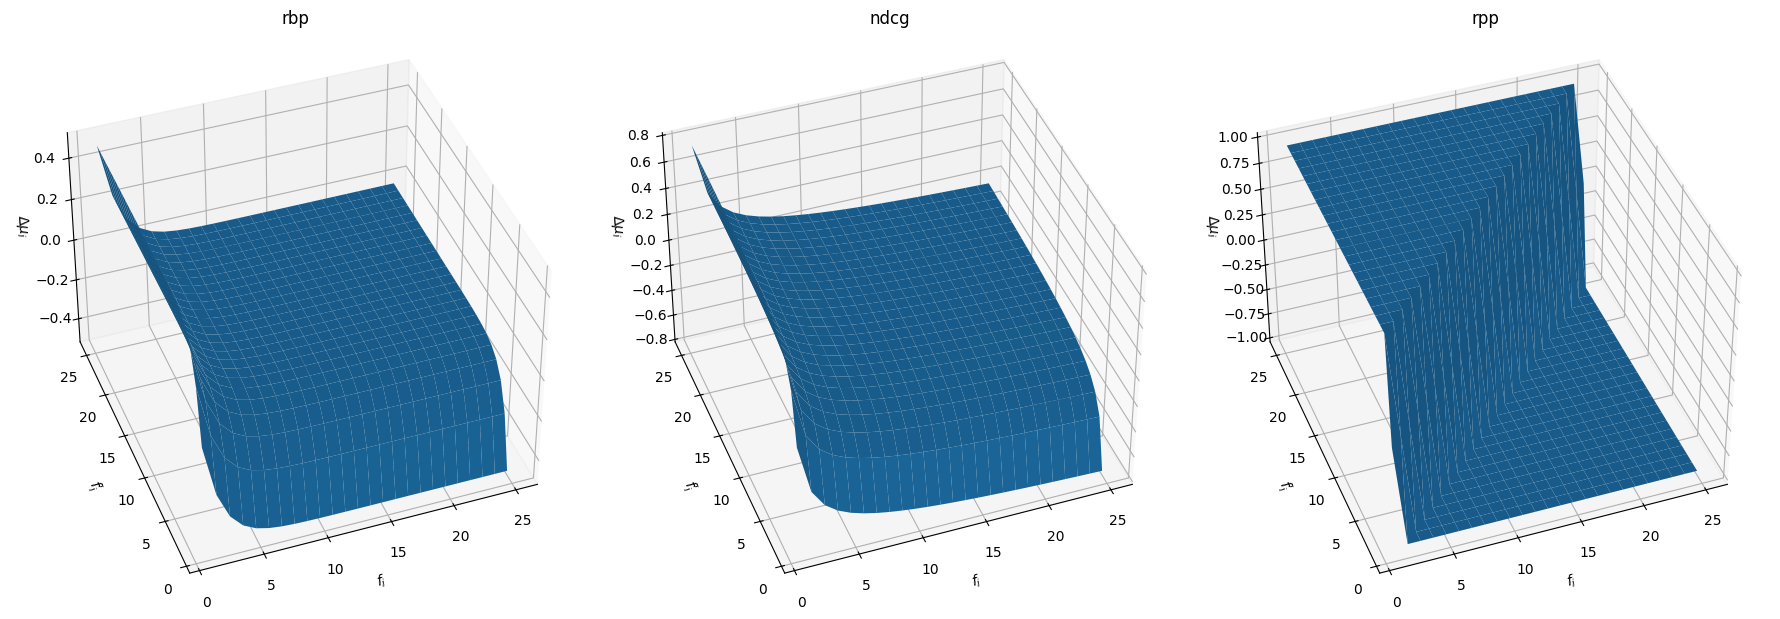

In [59]:
def delta_mu_rbp(f, f_prime, gamma: float = 0.5):
    return gamma**f - gamma**f_prime


def delta_mu_ndcg(f, f_prime):
    return 1 / np.log2(f + 1) - 1 / np.log2(f_prime + 1)


def delta_mu_rpp(f, f_prime):
    return np.sign(f_prime - f)


functions = {
    "rbp": delta_mu_rbp,
    "ndcg": delta_mu_ndcg,
    "rpp": delta_mu_rpp,
}

f, f_prime = np.meshgrid(np.arange(1, 26), np.arange(1, 26))


fig, axes = plt.subplots(
    1,
    len(functions),
    figsize=(18, 6),
    subplot_kw={"projection": "3d"},
)

for ax, (name, func) in zip(axes.flatten(), functions.items()):
    ax.set_title(name)
    z = func(f, f_prime)
    ax.plot_surface(f, f_prime, z)
    ax.set_xlabel("$f_i$")
    ax.set_ylabel("$f_i'$")
    ax.set_zlabel(r"$\Delta \mu_i$")

    ax.view_init(elev=40, azim=-110)

fig.tight_layout()
plt.show()